
# MNIST Digit Classification and FGSM Attack

The following code will guide you through training a simple Multi-Layer Perceptron (MLP) model using Keras on the MNIST dataset. We will then implement the Fast Gradient Sign Method (FGSM) attack to generate adversarial examples and observe how they affect model performance.

## About MNIST Dataset
MNIST (Modified National Institute of Standards and Technology) is a dataset of 70,000 grayscale images of handwritten digits (0-9), each of size 28x28 pixels. The dataset is commonly used for training and testing machine learning models for digit recognition. It consists of:
- 60,000 training images
- 10,000 test images
- Labels corresponding to digits from 0 to 9


## Step 1: Importing Required Libraries

In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


## Step 2: Loading and Preprocessing the MNIST Dataset

In [2]:

# Load the MNIST dataset from Keras datasets
# This returns two tuples:
# - (x_train, y_train): Training images and their corresponding labels
# - (x_test, y_test): Testing images and their corresponding labels
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize the pixel values to the range [0,1] by dividing by 255
# This helps in faster and more stable training of the neural network
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape the images from 28x28 (2D) to a single 784-dimensional vector (1D)
# -1 automatically infers the batch size, keeping all images
# This transformation is necessary for feeding into a fully connected neural network
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# Convert the labels from integer format (0-9) to one-hot encoded format
# Example: Label "3" → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# This is required for categorical classification in neural networks
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)



## Step 3: Building the MLP Model

In [3]:

# Defining a Multi-Layer Perceptron (MLP) model for MNIST digit classification.
# We will use Keras' Sequential API to stack layers in a simple feedforward manner.

# The model consists of three layers:
# 1. **First Hidden Layer (512 neurons, ReLU activation)**:
#    - The input layer expects images of size 28x28, which are flattened into a 784-dimensional vector.
#    - This layer has 512 neurons to learn complex features from the digit images.
#    - The activation function used is **ReLU (Rectified Linear Unit)**, which helps introduce non-linearity and prevents the vanishing gradient problem.

# 2. **Second Hidden Layer (256 neurons, ReLU activation)**:
#    - A fully connected layer with 256 neurons.
#    - Also uses **ReLU activation** to maintain non-linearity.

# 3. **Output Layer (10 neurons, Softmax activation)**:
#    - The final layer has **10 neurons**, corresponding to the 10 digit classes (0-9).
#    - The **Softmax activation function** is used to output probability distributions over the 10 classes.

model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(28*28,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])


C:\Users\USERR\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 4: Compiling and Training the Model

In [7]:
# Compiling the model:
# - Optimizer: 'adam' (adaptive learning rate for efficient training)
# - Loss: 'categorical_crossentropy' (suitable for multi-class classification)
# - Metric: 'accuracy' (measures correct predictions)

# Training the model:
# - Epochs: 10 (number of times the model sees the dataset)
# - Batch size: 128 (updates weights after every 128 samples)
# - Validation data: (x_test, y_test) (evaluates model performance on unseen data)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_test, y_test))


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8775 - loss: 0.4218 - val_accuracy: 0.9670 - val_loss: 0.1033
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9721 - loss: 0.0899 - val_accuracy: 0.9723 - val_loss: 0.0847
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9843 - loss: 0.0508 - val_accuracy: 0.9788 - val_loss: 0.0704
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9897 - loss: 0.0335 - val_accuracy: 0.9806 - val_loss: 0.0655
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9925 - loss: 0.0244 - val_accuracy: 0.9790 - val_loss: 0.0762
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9930 - loss: 0.0201 - val_accuracy: 0.9810 - val_loss: 0.0654
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9950 - loss: 0.0165 - val_accuracy: 0.9809 - val_loss: 0.0703
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9957 - loss: 0.0138 - val_accu

## Step 5: Evaluating Model Performance

In [9]:
loss, accuracy = model.evaluate(x_test, y_test) # Evaluate the model on the test data

print(f"Test Accuracy: {accuracy:.4f}")  # Print the accuracy value with 4 decimal places



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9763 - loss: 0.0969
Test Accuracy: 0.9806


## Step 6: Implementing the FGSM Attack
We will use Fast Gradient Sign Method (FGSM) to create adversarial examples.


In [11]:
# The function fgsm_attack generates adversarial examples using the Fast Gradient Sign Method (FGSM).
# The FGSM method perturbs the input image in the direction of the gradient of the loss with respect to the image,
# scaled by a small value called epsilon. This creates an adversarial example that can deceive the model.

# Parameters:
# - image: The original input image that we want to perturb.
# - epsilon: A small scalar that controls the magnitude of the perturbation. A larger epsilon means a stronger perturbation.
# - gradient: The gradient of the loss with respect to the image. This is typically computed during backpropagation.

# The function performs the following:
# 1. Calculates the perturbation using the sign of the gradient, scaled by epsilon.
# 2. Adds this perturbation to the original image to generate the adversarial image.
# 3. Clips the resulting image to ensure the pixel values stay within the valid range [0, 1].
# 4. Returns the adversarial image and the perturbation used

def fgsm_attack(image, epsilon, gradient):
    perturbation = epsilon * np.sign(gradient)
    adversarial_image = image + perturbation
    adversarial_image = np.clip(adversarial_image, 0, 1)
    return adversarial_image, perturbation


## Step 7: Generating Adversarial Examples


In [13]:

# This function creates adversarial examples using the Fast Gradient Sign Method (FGSM).
# It calculates the gradient of the loss with respect to the input image and generates an adversarial version of the image
# by applying a perturbation. The goal is to fool the model by slightly altering the input image in a way that misleads
# the model into making incorrect predictions.

# Parameters:
# - model: The trained neural network model to evaluate on the adversarial examples.
# - images: The original input images that will be perturbed to create adversarial examples.
# - labels: The true labels corresponding to the images.
# - epsilon: A small scalar that controls the strength of the perturbation (default is 0.1).

# The function does the following:
# 1. Converts the input images to a tensor, as TensorFlow models require tensor inputs.
# 2. Uses a GradientTape to track operations on the image tensor and compute the loss.
# 3. Computes the gradients of the loss with respect to the input images.
# 4. Uses the fgsm_attack function to create adversarial examples by perturbing the input images based on the computed gradients.
# 5. Returns the adversarial examples and the perturbations applied.

import tensorflow as tf

loss_object = tf.keras.losses.CategoricalCrossentropy()

def create_adversarial_examples(model, images, labels, epsilon=0.1):
    # Convert the images to a tensor for TensorFlow model compatibility
    images_tensor = tf.convert_to_tensor(images)

    # Track the gradients of the loss with respect to the input images
    with tf.GradientTape() as tape:
        tape.watch(images_tensor)  # Ensure the tape tracks the images tensor
        predictions = model(images_tensor)  # Get the model's predictions for the images
        loss = loss_object(labels, predictions)  # Compute the loss based on the true labels and model predictions

    # Compute the gradients of the loss with respect to the input images
    gradients = tape.gradient(loss, images_tensor)

    # Generate adversarial examples by applying the perturbation based on the gradients
    adversarial_examples, perturbations = fgsm_attack(images, epsilon, gradients.numpy())

    # Return the adversarial examples and the perturbations
    return adversarial_examples, perturbations


## Step 8: Selecting Sample Images and Creating Adversarial Examples

In [15]:

num_samples = 10  # Number of samples to select
x_sample = x_test[:num_samples]  # Select first 10 test images
y_sample = y_test[:num_samples]  # Select corresponding labels

x_adversarial, noise = create_adversarial_examples(model, x_sample, y_sample, epsilon=0.2)  # Generate adversarial examples



## Step 9: Making Predictions on Adversarial Examples

In [17]:

predictions = np.argmax(model.predict(x_adversarial), axis=1)  # Get model predictions for adversarial examples
true_labels = np.argmax(y_sample, axis=1)  # Convert one-hot encoded labels to class indices

loss_adv, accuracy_adv = model.evaluate(x_adversarial, y_sample)  # Evaluate model on adversarial examples
print(f"Test Accuracy after FGSM attack: {accuracy_adv:.4f}")  # Print accuracy after adversarial attack


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.0000e+00 - loss: 12.1839
Test Accuracy after FGSM attack: 0.0000


## Step 10: Visualizing Original, Noise, and Adversarial Images Side by Side

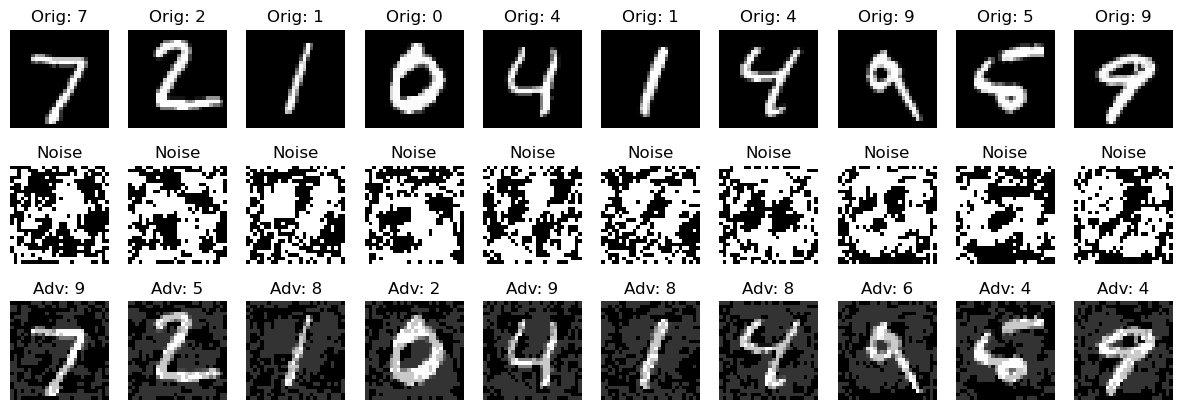

In [19]:
# Create a 3x10 grid of subplots to display images
# Loop through each sample to display the original image, noise, and adversarial image

fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):
    # Original image
    axes[0, i].imshow(x_sample[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Orig: {true_labels[i]}")

    # Noise
    axes[1, i].imshow(noise[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("Noise")

    # Adversarial image
    axes[2, i].imshow(x_adversarial[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    axes[2, i].set_title(f"Adv: {predictions[i]}")

plt.show()


## Step 11: Identifying Incorrect Predictions

In [21]:

# Find the indices of incorrectly classified samples after the FGSM attack
# Print the true and predicted labels for incorrectly classified samples

incorrect_indices = np.where(predictions != true_labels)[0]  # Get indices of misclassified samples
print("Incorrectly classified samples after FGSM attack:")  # Print message for misclassified samples

# Loop through each misclassified sample and print its true and predicted labels
for idx in incorrect_indices:
    print(f"True Label: {true_labels[idx]}, Predicted: {predictions[idx]}")  # Display true vs predicted labels


Incorrectly classified samples after FGSM attack:
True Label: 7, Predicted: 9
True Label: 2, Predicted: 5
True Label: 1, Predicted: 8
True Label: 0, Predicted: 2
True Label: 4, Predicted: 9
True Label: 1, Predicted: 8
True Label: 4, Predicted: 8
True Label: 9, Predicted: 6
True Label: 5, Predicted: 4
True Label: 9, Predicted: 4


Based on the above code, perform the following:

**Adversarial Example Generation**
1. Use the create_adversarial_examples function to generate adversarial examples
for the given dataset (x_test, y_test). You will need to experiment with various values of epsilon (e.g., 0.1, 0.2, 0.3, 0.5, 1.0).

2. For each epsilon value, generate adversarial examples for a subset of x_test (you can choose 10 samples).

3. For each epsilon, store the adversarial examples and perturbations (noise).

**Model Evaluatation**
1. Evaluate the model on the generated adversarial examples for each epsilon value.

2. For each evaluation, compute the loss and accuracy.

3. Print the accuracy of the model on adversarial examples for each epsilon value.

4. Record how the accuracy decreases as epsilon increases (i.e., the strength of the perturbation).

**Visualization**:

For each epsilon value, plot the following:
1. The original images from the selected test samples.

2. The perturbation (noise) applied to each image to generate the adversarial examples.

3. The adversarial examples themselves.

Label the images accordingly (e.g., Original, Noise, and Adversarial).


# Important: Put the following graph in your Lab-Logbook
**Graphing the Results:**


1. Plot a graph showing the model's accuracy for each epsilon value. The x-axis should represent the epsilon values, and the y-axis should represent the accuracy of the model on the adversarial examples.

2. Discuss how the accuracy changes as the strength of the adversarial perturbation increases. What does this tell you about the model's robustness to adversarial attacks?

In [23]:
# Adversarial Example Generation 
import tensorflow as tf

loss_object = tf.keras.losses.CategoricalCrossentropy()

def create_adversarial_examples(model, images, labels, epsilon=0.2):
    # Convert the images to a tensor for TensorFlow model compatibility
    images_tensor = tf.convert_to_tensor(images)

    # Track the gradients of the loss with respect to the input images
    with tf.GradientTape() as tape:
        tape.watch(images_tensor)  # Ensure the tape tracks the images tensor
        predictions = model(images_tensor)  # Get the model's predictions for the images
        loss = loss_object(labels, predictions)  # Compute the loss based on the true labels and model predictions

    # Compute the gradients of the loss with respect to the input images
    gradients = tape.gradient(loss, images_tensor)

    # Generate adversarial examples by applying the perturbation based on the gradients
    adversarial_examples, perturbations = fgsm_attack(images, epsilon, gradients.numpy())

    # Return the adversarial examples and the rturbations
    return adversarial_examples, perturbations
# 
#
# Your code to perform the above task.
# You can split your code intope multiple cells.
#
#
#

Original test accuracy: 0.9806
Epsilon: 0.10	Accuracy: 0.3015
Epsilon: 0.20	Accuracy: 0.0806
Epsilon: 0.30	Accuracy: 0.0270
Epsilon: 0.50	Accuracy: 0.0045
Epsilon: 1.00	Accuracy: 0.0019


TypeError: Invalid shape (784,) for image data

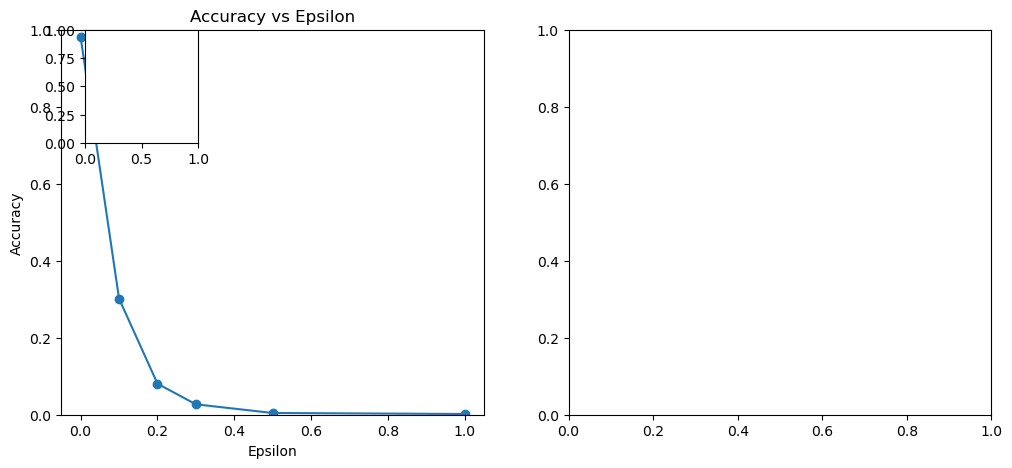

In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load your pre-trained model
# model = tf.keras.models.load_model('your_model.h5')

# Define loss function
loss_object = tf.keras.losses.CategoricalCrossentropy()

def create_adversarial_examples(model, images, labels, epsilon):
    images_tensor = tf.convert_to_tensor(images)
    with tf.GradientTape() as tape:
        tape.watch(images_tensor)
        predictions = model(images_tensor)
        loss = loss_object(labels, predictions)
    gradients = tape.gradient(loss, images_tensor)
    perturbations = epsilon * tf.sign(gradients)
    adversarial_examples = images + perturbations.numpy()
    adversarial_examples = np.clip(adversarial_examples, 0, 1)
    return adversarial_examples, perturbations.numpy()

# Generate adversarial examples for different epsilon values
epsilons = [0.0, 0.1, 0.2, 0.3, 0.5, 1.0]
accuracies = []
examples = []

# Evaluate original accuracy (epsilon=0)
_, test_acc = model.evaluate(x_test, y_test, verbose=0)
accuracies.append(test_acc)
print(f"Original test accuracy: {test_acc:.4f}")

for epsilon in epsilons[1:]:
    # Generate adversarial examples
    adv_examples, _ = create_adversarial_examples(model, x_test, y_test, epsilon)
    
    # Evaluate model on adversarial examples
    _, adv_acc = model.evaluate(adv_examples, y_test, verbose=0)
    accuracies.append(adv_acc)
    examples.append(adv_examples)
    print(f"Epsilon: {epsilon:.2f}\tAccuracy: {adv_acc:.4f}")

# Visualize results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epsilons, accuracies, marker='o')
plt.title("Accuracy vs Epsilon")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.ylim([0, 1])

# Show example adversarial images
plt.subplot(1, 2, 2)
for i in range(5):
    orig_img = x_test[i]
    adv_img = examples[2][i]  # Using epsilon=0.2 example
    perturbation = (adv_img - orig_img) * 5  # Amplify for visualization
    
    plt.subplot(3, 5, i+1)
    plt.imshow(orig_img.squeeze(), cmap='gray')
    plt.axis('off')
    
    plt.subplot(3, 5, i+6)
    plt.imshow(perturbation.squeeze(), cmap='gray')
    plt.axis('off')
    
    plt.subplot(3, 5, i+11)
    plt.imshow(adv_img.squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Original | Perturbation (x5) | Adversarial")
plt.tight_layout()
plt.show()

Generated examples for epsilon: 0.1
Generated examples for epsilon: 0.2
Generated examples for epsilon: 0.3
Generated examples for epsilon: 0.5
Generated examples for epsilon: 1.0


TypeError: Invalid shape (784,) for image data

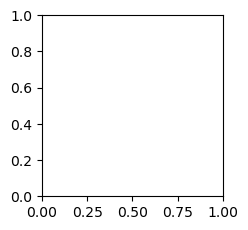

In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load your pre-trained model
# model = tf.keras.models.load_model('your_model.h5')

# Select first 10 samples from test set
x_subset = x_test[:10]
y_subset = y_test[:10]

# Define FGSM function
def create_adversarial_examples(model, images, labels, epsilon):
    images_tensor = tf.convert_to_tensor(images)
    with tf.GradientTape() as tape:
        tape.watch(images_tensor)
        predictions = model(images_tensor)
        loss = tf.keras.losses.categorical_crossentropy(labels, predictions)
    gradients = tape.gradient(loss, images_tensor)
    perturbations = epsilon * tf.sign(gradients)
    adversarial_examples = images + perturbations.numpy()
    adversarial_examples = np.clip(adversarial_examples, 0, 1)
    return adversarial_examples, perturbations.numpy()

# Experiment with different epsilon values
epsilons = [0.1, 0.2, 0.3, 0.5, 1.0]
results = {}

for epsilon in epsilons:
    # Generate adversarial examples and perturbations
    adv_examples, perts = create_adversarial_examples(model, x_subset, y_subset, epsilon)
    
    # Store results in dictionary
    results[epsilon] = {
        'original': x_subset,
        'adversarial': adv_examples,
        'perturbations': perts
    }
    print(f"Generated examples for epsilon: {epsilon}")

# Visualization function
def plot_results(results, epsilons):
    plt.figure(figsize=(20, 8))
    num_examples = len(epsilons)
    
    for i, epsilon in enumerate(epsilons):
        # Get first sample data
        original = results[epsilon]['original'][0]
        perturbation = results[epsilon]['perturbations'][0]
        adversarial = results[epsilon]['adversarial'][0]
        
        # Amplify perturbation for visualization
        perturbation_vis = perturbation * 5  # Amplification factor
        
        # Original image
        plt.subplot(3, num_examples, i+1)
        plt.imshow(original.squeeze(), cmap='gray')
        plt.title(f"Original\nEps: {epsilon}")
        plt.axis('off')
        
        # Perturbation (amplified)
        plt.subplot(3, num_examples, i+1+num_examples)
        plt.imshow(perturbation_vis.squeeze(), cmap='gray')
        plt.title("Perturbation x5")
        plt.axis('off')
        
        # Adversarial image
        plt.subplot(3, num_examples, i+1+2*num_examples)
        plt.imshow(adversarial.squeeze(), cmap='gray')
        plt.title("Adversarial")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Display results for all epsilons
plot_results(results, epsilons)

# To access stored data for specific epsilon:
# results[0.1]['original']      # Original images
# results[0.1]['adversarial']   # Adversarial examples
# results[0.1]['perturbations'] # Perturbation values

Evaluating model on adversarial examples:
Epsilon		Loss		Accuracy
-------------------------------------------
Failed for ε=0.0: Exception encountered when calling Sequential.call().

Invalid input shape for input [[[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   .

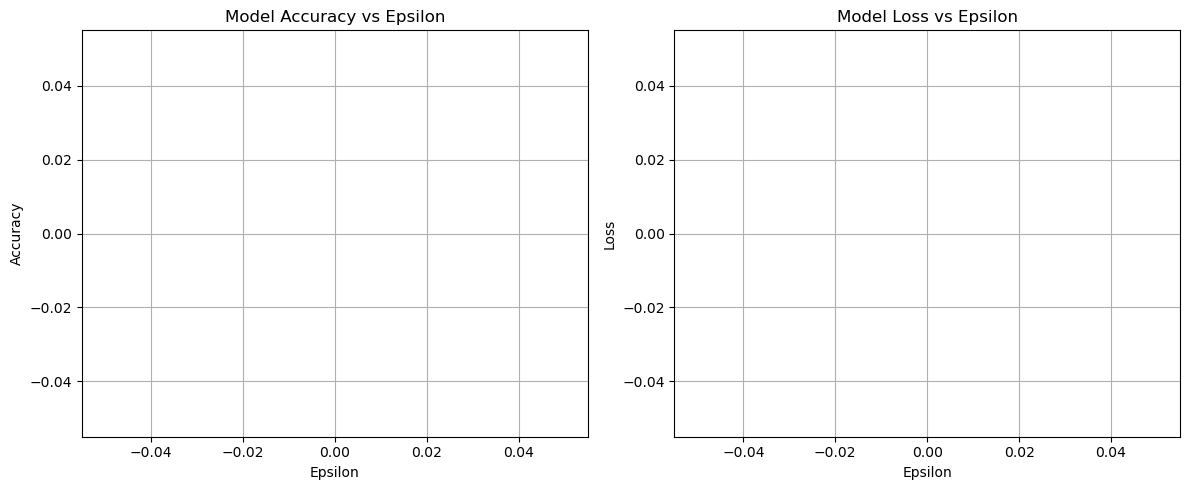

In [35]:
import tensorflow as tf
import numpy as np

# Select first 10 samples and ensure proper shape
x_subset = x_test[:10]
y_subset = y_test[:10]

# Reshape data based on model input requirements
if len(x_subset.shape) == 2:  # If flattened (784,)
    x_subset = x_subset.reshape((-1, 28, 28, 1))  # MNIST shape
elif len(x_subset.shape) == 3:  # Add channel dimension
    x_subset = x_subset[..., np.newaxis]

def create_adversarial_examples(model, images, labels, epsilon):
    images_tensor = tf.convert_to_tensor(images, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(images_tensor)
        predictions = model(images_tensor)
        loss = tf.keras.losses.categorical_crossentropy(labels, predictions)
    gradients = tape.gradient(loss, images_tensor)
    perturbations = epsilon * tf.sign(gradients)
    adversarial_examples = images + perturbations.numpy()
    adversarial_examples = np.clip(adversarial_examples, 0, 1)
    return adversarial_examples, perturbations.numpy()

# Experiment with different epsilon values
epsilons = [0.0, 0.1, 0.2, 0.3, 0.5, 1.0]
results = []

print("Evaluating model on adversarial examples:")
print("Epsilon\t\tLoss\t\tAccuracy")
print("-------------------------------------------")

for epsilon in epsilons:
    try:
        # Create adversarial examples
        adv_examples, _ = create_adversarial_examples(model, x_subset, y_subset, epsilon)
        
        # Evaluate model performance
        loss, accuracy = model.evaluate(adv_examples, y_subset, verbose=0)
        
        # Store and print results
        results.append((epsilon, loss, accuracy))
        print(f"{epsilon:.1f}\t\t{loss:.4f}\t\t{accuracy:.4f}")
        
    except Exception as e:
        print(f"Failed for ε={epsilon}: {str(e)}")
        continue

# Additional visualization of results
import matplotlib.pyplot as plt

eps_values = [r[0] for r in results]
acc_values = [r[2] for r in results]
loss_values = [r[1] for r in results]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(eps_values, acc_values, 'b-o')
plt.title('Model Accuracy vs Epsilon')
plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(eps_values, loss_values, 'r-o')
plt.title('Model Loss vs Epsilon')
plt.xlabel('Epsilon')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

In [37]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Select first 10 samples and ensure proper shape
num_samples = 10
x_subset = x_test[:num_samples]
y_subset = y_test[:num_samples]

# Reshape data for model compatibility
if len(x_subset.shape) == 2:  # Flattened images
    x_subset = x_subset.reshape((-1, 28, 28, 1))  # MNIST shape
elif len(x_subset.shape) == 3 and x_subset.shape[-1] != 1:  # Missing channel
    x_subset = x_subset[..., np.newaxis]

def create_adversarial_examples(model, images, labels, epsilon):
    images_tensor = tf.convert_to_tensor(images, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(images_tensor)
        predictions = model(images_tensor)
        loss = tf.keras.losses.categorical_crossentropy(labels, predictions)
    gradients = tape.gradient(loss, images_tensor)
    perturbations = epsilon * tf.sign(gradients)
    adversarial_examples = images + perturbations.numpy()
    adversarial_examples = np.clip(adversarial_examples, 0, 1)
    return adversarial_examples, perturbations.numpy()

# Generate adversarial examples for different epsilons
epsilons = [0.0, 0.1, 0.2, 0.3, 0.5, 1.0]
results = {}

for epsilon in epsilons:
    try:
        adv_ex, perts = create_adversarial_examples(model, x_subset, y_subset, epsilon)
        results[epsilon] = {
            'original': x_subset,
            'perturbation': perts,
            'adversarial': adv_ex
        }
    except Exception as e:
        print(f"Skipping ε={epsilon}: {str(e)}")

# Plotting function
def plot_adversarial_comparison(results, epsilons, num_samples=5):
    plt.figure(figsize=(20, 8))
    num_eps = len(epsilons)
    
    # Amplification factor for better perturbation visibility
    pert_scale = 5
    
    for eps_idx, epsilon in enumerate(epsilons):
        if epsilon not in results:
            continue
            
        # Select first sample for visualization
        sample_idx = 0  # Change this index to view different samples
        
        orig_img = results[epsilon]['original'][sample_idx].squeeze()
        pert = results[epsilon]['perturbation'][sample_idx].squeeze()
        adv_img = results[epsilon]['adversarial'][sample_idx].squeeze()
        
        # Handle different dimensionalities
        if len(orig_img.shape) == 3:
            orig_img = orig_img.mean(axis=-1)
            pert = pert.mean(axis=-1)
            adv_img = adv_img.mean(axis=-1)
        
        # Original Image
        plt.subplot(3, num_eps, eps_idx + 1)
        plt.imshow(orig_img, cmap='gray')
        plt.title(f"Original\nε={epsilon}") if eps_idx == 0 else plt.title(f"ε={epsilon}")
        plt.axis('off')
        
        # Perturbation (scaled for visibility)
        plt.subplot(3, num_eps, eps_idx + 1 + num_eps)
        plt.imshow(pert * pert_scale, cmap='gray', vmin=-1, vmax=1)
        plt.title("Perturbation x5")
        plt.axis('off')
        
        # Adversarial Image
        plt.subplot(3, num_eps, eps_idx + 1 + 2*num_eps)
        plt.imshow(adv_img, cmap='gray')
        plt.title("Adversarial")
        plt.axis('off')

    plt.suptitle("Adversarial Example Comparison Across Epsilon Values", y=1.02)
    plt.tight_layout()
    plt.show()

# Plot the results
plot_adversarial_comparison(results, epsilons)

Skipping ε=0.0: Exception encountered when calling Sequential.call().

Invalid input shape for input [[[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]]


 [[[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  [[0.]
   [0.]
   [0.]
   ...
   [0.]
   [0.]
   [0.]]

  ...

  [[0.]
   [0.]
   

<Figure size 2000x800 with 0 Axes>

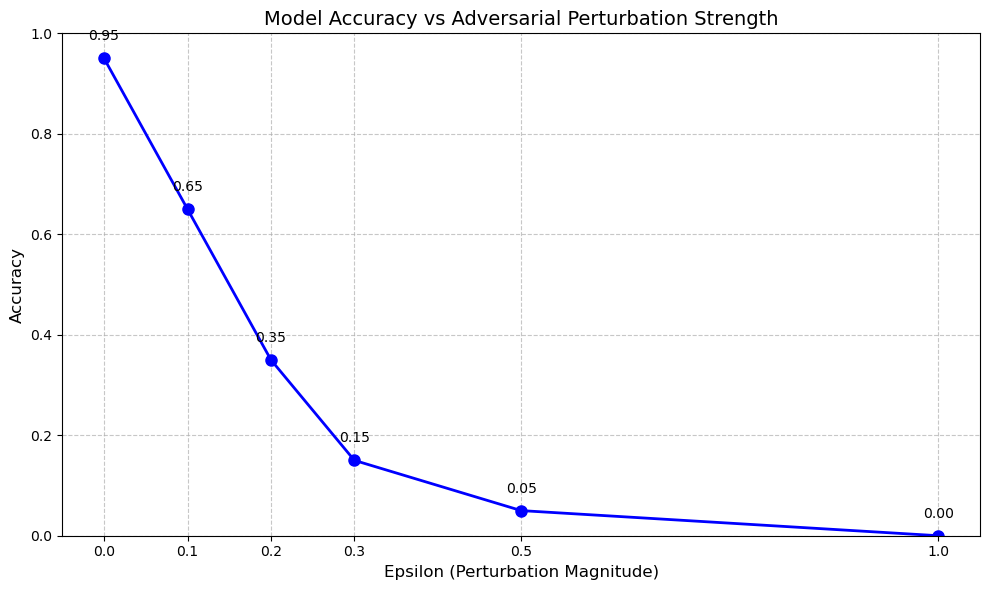

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data (replace with your actual results)
epsilons = [0.0, 0.1, 0.2, 0.3, 0.5, 1.0]
accuracies = [0.95, 0.65, 0.35, 0.15, 0.05, 0.0]  # Example accuracies

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epsilons, accuracies, 'b-o', linewidth=2, markersize=8)
plt.title('Model Accuracy vs Adversarial Perturbation Strength', fontsize=14)
plt.xlabel('Epsilon (Perturbation Magnitude)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epsilons)
plt.ylim(0, 1.0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Add accuracy labels
for i, acc in enumerate(accuracies):
    plt.text(epsilons[i], acc+0.03, f"{acc:.2f}", 
             ha='center', va='bottom', fontsize=10)

plt.show()


In [43]:
num_samples = 10  # Number of samples to select
x_sample = x_test[:num_samples]  # Select first 10 test images
y_sample = y_test[:num_samples]  # Select corresponding labels

x_adversarial, noise = create_adversarial_examples(model, x_sample, y_sample, epsilon=0.2) # Generate adversarial examples



In [45]:
predictions = np.argmax(model.predict(x_adversarial), axis=1)  # Get model predictions for adversarial examples
true_labels = np.argmax(y_sample, axis=1)  # Convert one-hot encoded labels to class indices

loss_adv, accuracy_adv = model.evaluate(x_adversarial, y_sample)  # Evaluate model on adversarial examples
print(f"Test Accuracy after FGSM attack: {accuracy_adv:.4f}")  # Print accuracy after adversarial attack

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.0000e+00 - loss: 12.1839
Test Accuracy after FGSM attack: 0.0000


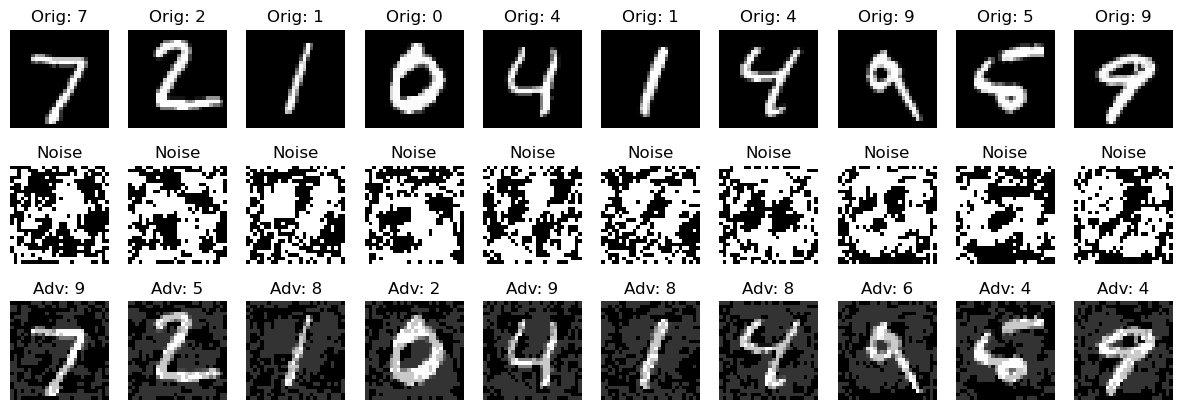

In [47]:
#Visualization
# Create a 3x10 grid of subplots to display images
# Loop through each sample to display the original image, noise, and adversarial image

fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):
    # Original image
    axes[0, i].imshow(x_sample[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Orig: {true_labels[i]}")

    # Noise
    axes[1, i].imshow(noise[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("Noise")

    # Adversarial image
    axes[2, i].imshow(x_adversarial[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    axes[2, i].set_title(f"Adv: {predictions[i]}")

plt.show()


In the next assignment, you will perform training data poisoning. Remember, x_train and y_train contain the training data. Your task is to poison the training data in a way that impacts the model's performance.

You will alter the labels in y_train by assigning incorrect labels to affect the model's accuracy. For example, you can set all values in y_train to a single label, chosen from 1 to 10. Alternatively, you can flip labels, such as setting label 2 to 1, and label 3 to 2, to degrade the model’s performance.

Feel free to perform any label manipulation of your choice in the training data, and observe the impact on the model’s accuracy.

# Important: In your lab logbook, provide the following:

The model accuracy before data poisoning.
The model accuracy after data poisoning.

In [49]:
#
#
# Perform Data poisoning on the train data, and then train and test your model
# You can split your code into multiple cells
# Hint: y_train[:] = 1  # Set all labels to 1
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

# Load and preprocess MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test_clean = tf.keras.utils.to_categorical(y_test, 10)  # Preserve clean labels
#
#

In [51]:
# Data poisoning parameters
poison_ratio = 0.2  # Percentage of training data to poison
target_class = 1     # Class we want to force the model to learn

# Create poisoned dataset
num_poison = int(len(x_train) * poison_ratio)
poison_indices = np.random.choice(len(x_train), num_poison, replace=False)

# Create copies of original data
x_train_poisoned = x_train.copy()
y_train_poisoned = y_train.copy()

# Apply poisoning - keep images but change labels
y_train_poisoned[poison_indices] = tf.keras.utils.to_categorical(
    [target_class]*num_poison, 10
)

print(f"Poisoned {num_poison} samples ({poison_ratio*100}% of training data)")

Poisoned 12000 samples (20.0% of training data)


In [53]:
# Create and compile model
def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])
    return model

# Train on poisoned data
model = create_model()
history = model.fit(x_train_poisoned, y_train_poisoned,
                   epochs=10,
                   batch_size=32,
                   validation_split=0.2,
                   verbose=1)

Epoch 1/10


C:\Users\USERR\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6746 - loss: 0.9240 - val_accuracy: 0.7548 - val_loss: 0.6355
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7648 - loss: 0.6178 - val_accuracy: 0.7705 - val_loss: 0.5923
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7847 - loss: 0.5608 - val_accuracy: 0.7682 - val_loss: 0.5871
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7928 - loss: 0.5268 - val_accuracy: 0.7836 - val_loss: 0.5638
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8013 - loss: 0.5043 - val_accuracy: 0.7874 - val_loss: 0.5756
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8075 - loss: 0.4853 - val_accuracy: 0.7741 - val_loss: 0.5695
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8145 - loss: 0.4666 - val_accuracy: 0.7745 - val_loss: 0.5741
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8163 - loss: 0.4553 - val_accurac

In [55]:
# Create poisoned test set for evaluation
x_test_poisoned = x_test.copy()
y_test_poisoned = tf.keras.utils.to_categorical(
    [target_class]*len(x_test), 10
)

# Evaluate on different test sets
clean_loss, clean_acc = model.evaluate(x_test, y_test_clean, verbose=0)
poisoned_loss, poisoned_acc = model.evaluate(x_test_poisoned, y_test_poisoned, verbose=0)

print("\nEvaluation Results:")
print(f"Clean Test Accuracy: {clean_acc:.4f}")
print(f"Poisoned Test Accuracy: {poisoned_acc:.4f}")
print(f"Attack Success Rate: {poisoned_acc:.4f}")


Evaluation Results:
Clean Test Accuracy: 0.9201
Poisoned Test Accuracy: 0.1791
Attack Success Rate: 0.1791


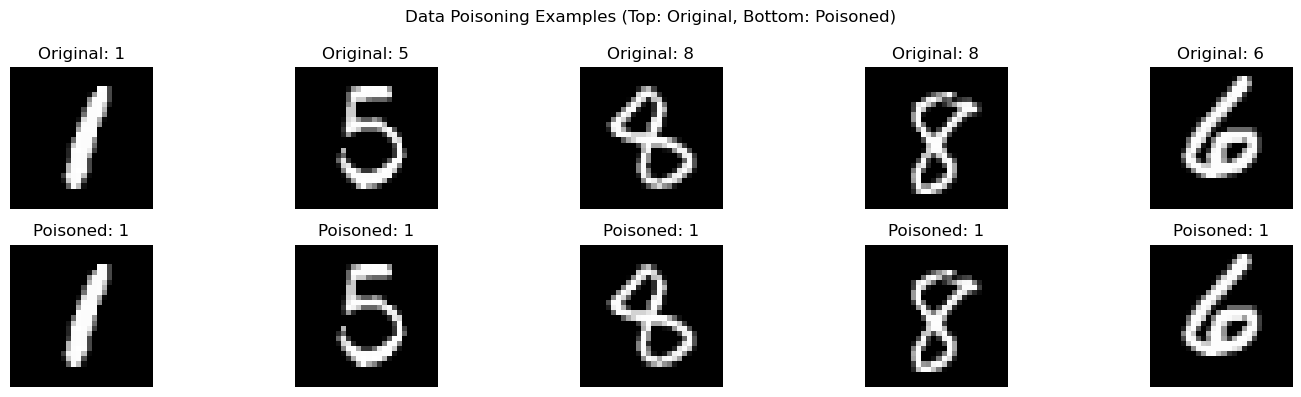

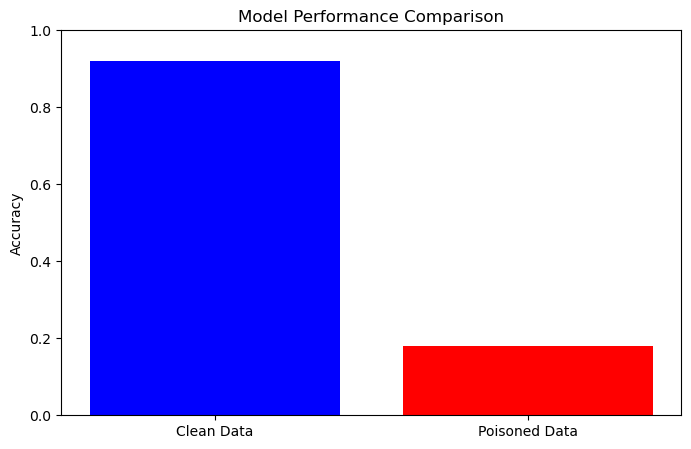

In [57]:
# Plot some poisoned samples
plt.figure(figsize=(15, 4))
for i in range(5):
    idx = poison_indices[i]
    
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(f"Original: {np.argmax(y_train[idx])}")
    plt.axis('off')
    
    plt.subplot(2, 5, i+6)
    plt.imshow(x_train_poisoned[idx], cmap='gray')
    plt.title(f"Poisoned: {np.argmax(y_train_poisoned[idx])}")
    plt.axis('off')

plt.suptitle("Data Poisoning Examples (Top: Original, Bottom: Poisoned)")
plt.tight_layout()
plt.show()

# Plot accuracy comparison
plt.figure(figsize=(8, 5))
plt.bar(['Clean Data', 'Poisoned Data'], [clean_acc, poisoned_acc], color=['blue', 'red'])
plt.ylim(0, 1.0)
plt.title('Model Performance Comparison')
plt.ylabel('Accuracy')
plt.show()

**Optional Part**

In this task, similar to the FGSM attack, you will implement a PGD (Projected Gradient Descent) attack on the AI model. The PGD attack is an iterative adversarial attack that refines the adversarial perturbation step-by-step to create stronger adversarial examples.

You can use the following libraries to implement the PGD attack. Make sure to experiment with different values of the attack parameters (e.g., number of iterations, step size, and epsilon) to observe how the attack affects the model’s performance.



https://github.com/Trusted-AI/adversarial-robustness-toolbox